In [5]:
import pandas as pd


In [6]:
Alz_df=pd.read_csv("alzheimers_disease_data.csv")
print(Alz_df.head())

   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   BehavioralProblems       ADL  Confusion  Disorientation  \
0     

In [7]:
print(Alz_df.describe())

         PatientID          Age       Gender    Ethnicity  EducationLevel  \
count  2149.000000  2149.000000  2149.000000  2149.000000     2149.000000   
mean   5825.000000    74.908795     0.506282     0.697534        1.286645   
std     620.507185     8.990221     0.500077     0.996128        0.904527   
min    4751.000000    60.000000     0.000000     0.000000        0.000000   
25%    5288.000000    67.000000     0.000000     0.000000        1.000000   
50%    5825.000000    75.000000     1.000000     0.000000        1.000000   
75%    6362.000000    83.000000     1.000000     1.000000        2.000000   
max    6899.000000    90.000000     1.000000     3.000000        3.000000   

               BMI      Smoking  AlcoholConsumption  PhysicalActivity  \
count  2149.000000  2149.000000         2149.000000       2149.000000   
mean     27.655697     0.288506           10.039442          4.920202   
std       7.217438     0.453173            5.757910          2.857191   
min      15.00

In [8]:
print(Alz_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [9]:
Alz_df.drop_duplicates(inplace=True)

In [10]:
Alz_df.columns=Alz_df.columns.str.upper().str.strip()

In [11]:
 from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


In [12]:
from sklearn.ensemble import RandomForestClassifier

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [34]:
uw=["PATIENTID","DOCTORINCHARGE"]

In [35]:
Alz_df= Alz_df.drop(columns=[col for col in uw if col in Alz_df.columns], errors='ignore')

In [36]:
Alz_df.fillna(Alz_df.median(numeric_only=True),inplace=True)

In [37]:
print(Alz_df.columns.tolist())

['AGE', 'GENDER', 'ETHNICITY', 'EDUCATIONLEVEL', 'BMI', 'SMOKING', 'ALCOHOLCONSUMPTION', 'PHYSICALACTIVITY', 'DIETQUALITY', 'SLEEPQUALITY', 'FAMILYHISTORYALZHEIMERS', 'CARDIOVASCULARDISEASE', 'DIABETES', 'DEPRESSION', 'HEADINJURY', 'HYPERTENSION', 'SYSTOLICBP', 'DIASTOLICBP', 'CHOLESTEROLTOTAL', 'CHOLESTEROLLDL', 'CHOLESTEROLHDL', 'CHOLESTEROLTRIGLYCERIDES', 'MMSE', 'FUNCTIONALASSESSMENT', 'MEMORYCOMPLAINTS', 'BEHAVIORALPROBLEMS', 'ADL', 'CONFUSION', 'DISORIENTATION', 'PERSONALITYCHANGES', 'DIFFICULTYCOMPLETINGTASKS', 'FORGETFULNESS', 'DIAGNOSIS']


In [38]:
X=Alz_df.drop(columns=["DIAGNOSIS"])
y = Alz_df["DIAGNOSIS"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [42]:
model=RandomForestClassifier(n_estimators=200,random_state=42)

In [41]:
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
model.fit(X_train,y_train)
print("Model Training Completed")
y_pred=model.predict(X_test)

Model Training Completed


In [51]:
accuracy= accuracy_score(y_test,y_pred)
print(f"Model Accuracy:{accuracy*100:.4f}%")

Model Accuracy:92.7907%


In [53]:
print("Classification Report:\n",classification_report(y_test,y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95       277
           1       0.96      0.83      0.89       153

    accuracy                           0.93       430
   macro avg       0.94      0.91      0.92       430
weighted avg       0.93      0.93      0.93       430



In [54]:
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [55]:
cv_score=cross_val_score(model,X,y,cv=skf,scoring="accuracy")

In [59]:
print("Cross-validation Accuracy Scores:",cv_score)
print(f"mean Accuracy:{cv_score.mean()*100:.4f}%")
print(f"Standard Deviation:{cv_score.std()*100:.4f}%")

Cross-validation Accuracy Scores: [0.94418605 0.91860465 0.9372093  0.94651163 0.94638695]
mean Accuracy:93.8580%
Standard Deviation:1.0547%


In [60]:
cm=confusion_matrix(y_test,y_pred)

<Axes: >

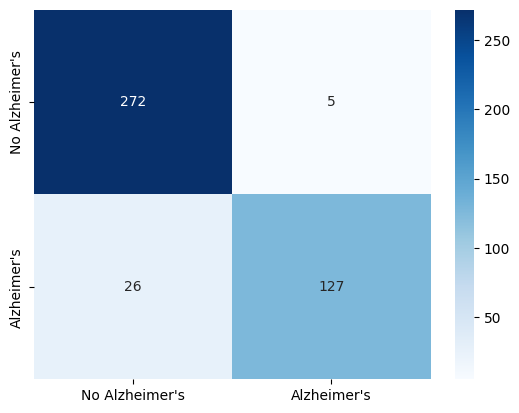

In [74]:
plt.Figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Alzheimer's","Alzheimer's"],
            yticklabels=["No Alzheimer's","Alzheimer's"])

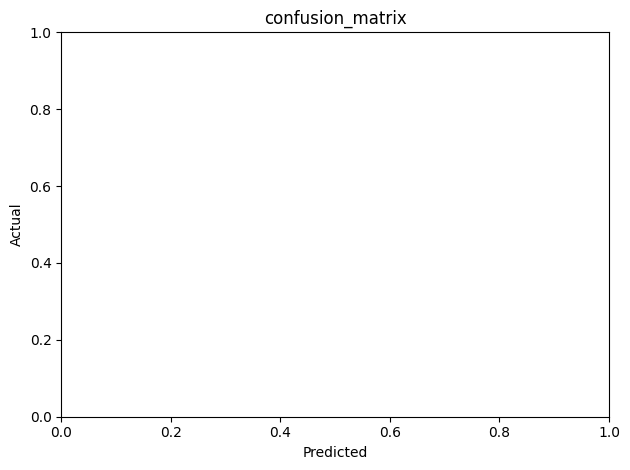

In [75]:
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion_matrix")
plt.tight_layout()
plt.show()

CSV File → Drop useless columns → Fill missing values
    → Split into X and y → 80/20 Train-Test Split
        → Train Random Forest → Predict on Test Set
            → Accuracy + Report → Cross-Validation → Confusion Matrix